In [9]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers.legacy import Adam # Using legacy because it runs faster on M1 Macs
import json
import re

In [10]:
stage = "river"

### Reading and compacting dfs

In [11]:
compact = False

In [12]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir("dfs"):
    if file.endswith(".parquet"):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(f"dfs/{file}", index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = "dfs/trash"
    for f in read:
        os.rename(f"dfs/{f}", f"{trash}/{f}")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f"dfs/compacted_{timestamp}.parquet")

dfs = []  # Clear memory
raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage,origin
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,41,6,47,True,True,True,88,579,river,tordjes_2024-05-01_06-48-49
1,0.001204,0.000293,0.000000,0.000104,0.000536,0.001024,0.001059,0.000867,0.001209,0.000550,...,235,32,267,True,False,True,502,2094,river,tordjes_2024-05-01_06-48-49
2,0.001788,0.000176,0.000937,0.000791,0.000269,0.000655,0.001059,0.001681,0.000103,0.001396,...,126,11,137,True,False,True,263,1028,river,tordjes_2024-05-01_06-48-49
3,0.001778,0.000009,0.000658,0.000000,0.000012,0.001520,0.001359,0.000186,0.001026,0.001158,...,299,71,336,True,True,True,635,1464,river,tordjes_2024-05-01_06-48-49
4,0.001159,0.000209,0.001263,0.000900,0.000477,0.000948,0.000051,0.000948,0.001068,0.000964,...,1,0,1,True,False,True,2,1218,river,tordjes_2024-05-01_06-48-49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15817,0.001184,0.001756,0.001501,0.001361,0.000055,0.000558,0.000528,0.000000,0.001175,0.001201,...,366,20,386,True,False,True,752,1527,river,tordjes_2024-04-30_23-16-57
15818,0.000637,0.000000,0.000769,0.000806,0.000000,0.001042,0.000939,0.001551,0.000383,0.001235,...,1,0,1,True,False,True,2,381,river,tordjes_2024-04-30_23-16-57
15819,0.000931,0.000512,0.001592,0.000072,0.000249,0.000891,0.000443,0.000324,0.000528,0.000602,...,260,15,275,True,False,True,535,1857,river,tordjes_2024-04-30_23-16-57
15820,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,293,50,343,True,False,True,636,1697,river,tordjes_2024-04-30_23-16-57


In [13]:
# Show all types of columns:
list(sorted(set(re.sub("\\d+", "X", col) for col in raw_df.columns)))

['game_size',
 'opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'origin',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'stage',
 'value_of_hand_X']

In [14]:
# Filter on stage
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage", "origin"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,41,6,47,True,True,True,88,579
1,0.001204,0.000293,0.000000,0.000104,0.000536,0.001024,0.001059,0.000867,0.001209,0.000550,...,0.0,0,235,32,267,True,False,True,502,2094
2,0.001788,0.000176,0.000937,0.000791,0.000269,0.000655,0.001059,0.001681,0.000103,0.001396,...,0.0,0,126,11,137,True,False,True,263,1028
3,0.001778,0.000009,0.000658,0.000000,0.000012,0.001520,0.001359,0.000186,0.001026,0.001158,...,0.0,34,299,71,336,True,True,True,635,1464
4,0.001159,0.000209,0.001263,0.000900,0.000477,0.000948,0.000051,0.000948,0.001068,0.000964,...,0.0,0,1,0,1,True,False,True,2,1218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15817,0.001184,0.001756,0.001501,0.001361,0.000055,0.000558,0.000528,0.000000,0.001175,0.001201,...,0.0,0,366,20,386,True,False,True,752,1527
15818,0.000637,0.000000,0.000769,0.000806,0.000000,0.001042,0.000939,0.001551,0.000383,0.001235,...,0.0,0,1,0,1,True,False,True,2,381
15819,0.000931,0.000512,0.001592,0.000072,0.000249,0.000891,0.000443,0.000324,0.000528,0.000602,...,0.0,0,260,15,275,True,False,True,535,1857
15820,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0,293,50,343,True,False,True,636,1697


### Preprocessing

In [15]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.000000,0.070812,0.010363,0.081174,0.151986
1,0.000000,0.112225,0.015282,0.127507,0.239733
2,0.000000,0.122568,0.010700,0.133268,0.255837
3,0.023224,0.204235,0.048497,0.229508,0.433743
4,0.000000,0.000821,0.000000,0.000821,0.001642
...,...,...,...,...,...
15817,0.000000,0.239686,0.013098,0.252783,0.492469
15818,0.000000,0.002625,0.000000,0.002625,0.005249
15819,0.000000,0.140011,0.008078,0.148088,0.288099
15820,0.000000,0.172658,0.029464,0.202121,0.374779


In [16]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713425 0.0007233015211020242
Mean and sd of range features after scaling:
-2.0556582516084987e-16 1.0000000000000029


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,...,-0.299720,1.352768,0.229497,0.243007,0.140470,0.289446,0.647718,1.213017,-0.891202,0.449325
1,0.621902,-0.636981,-1.042647,-0.898232,-0.301625,0.372762,0.421757,0.156283,0.628611,-0.282084,...,1.275631,1.354983,0.895973,0.362698,-0.800274,-0.875608,0.507503,-0.965053,1.316475,-0.739427
2,1.429851,-0.799811,0.253468,0.051477,-0.670090,-0.136648,0.422066,1.281182,-0.900806,0.887793,...,-1.042647,-1.042647,-0.842170,0.999651,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,0.133289
3,1.415601,-1.030666,-0.132412,-1.042647,-1.025496,1.059405,0.836247,-0.785360,0.375482,0.558972,...,-0.243874,-1.042647,0.622451,-0.048813,-1.042647,-0.742020,0.558533,-1.042647,-1.042647,-0.623883
4,0.559686,-0.753020,0.703728,0.201575,-0.382962,0.268090,-0.971946,0.267390,0.433488,0.290036,...,-0.156650,0.297411,1.097629,0.946517,0.252735,1.037671,-0.274974,1.102853,-0.559577,0.490765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15817,0.594406,1.384751,1.032946,0.838983,-0.966900,-0.270836,-0.312578,-1.042647,0.581963,0.617383,...,-1.042647,0.515351,-0.603087,0.259134,-1.042647,-1.042647,-1.042647,-0.137649,-1.010338,0.643051
15818,-0.162225,-1.042647,0.021008,0.071370,-1.042647,0.397741,0.255916,1.101135,-0.513085,0.664276,...,1.190051,1.235743,-1.042647,0.455597,0.421080,-1.042647,-0.539464,-1.042647,0.153550,-1.042647
15819,0.245092,-0.334914,1.158214,-0.942687,-0.698432,0.189789,-0.430495,-0.595032,-0.313221,-0.209943,...,1.038328,1.370493,0.951698,0.133556,-0.914855,0.428290,-0.451355,1.015883,-1.040683,-0.961084
15820,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,...,0.160395,-0.796079,-1.042647,-0.704538,0.456650,-1.042647,-0.663880,-1.042647,-0.837582,-1.042647


In [17]:
# Make boolean features 0 or 1
bool_columns = [
    "player_turn",
    "player_has_bet",
    "opponent_has_bet",
]


def encode_bools(df):
    df[bool_columns] = df[bool_columns].astype(int)


encode_bools(df)
df[bool_columns]

,player_turn,player_has_bet,opponent_has_bet
0,1,1,1
1,1,0,1
2,1,0,1
3,1,1,1
4,1,0,1
...,...,...,...
15817,1,0,1
15818,1,0,1
15819,1,0,1
15820,1,0,1


In [18]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,...,0.0,0.0,0.000000,0.070812,0.010363,0.081174,1,1,1,0.151986
1,0.621902,-0.636981,-1.042647,-0.898232,-0.301625,0.372762,0.421757,0.156283,0.628611,-0.282084,...,0.0,0.0,0.000000,0.112225,0.015282,0.127507,1,0,1,0.239733
2,1.429851,-0.799811,0.253468,0.051477,-0.670090,-0.136648,0.422066,1.281182,-0.900806,0.887793,...,0.0,0.0,0.000000,0.122568,0.010700,0.133268,1,0,1,0.255837
3,1.415601,-1.030666,-0.132412,-1.042647,-1.025496,1.059405,0.836247,-0.785360,0.375482,0.558972,...,0.0,0.0,0.023224,0.204235,0.048497,0.229508,1,1,1,0.433743
4,0.559686,-0.753020,0.703728,0.201575,-0.382962,0.268090,-0.971946,0.267390,0.433488,0.290036,...,0.0,0.0,0.000000,0.000821,0.000000,0.000821,1,0,1,0.001642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15817,0.594406,1.384751,1.032946,0.838983,-0.966900,-0.270836,-0.312578,-1.042647,0.581963,0.617383,...,0.0,0.0,0.000000,0.239686,0.013098,0.252783,1,0,1,0.492469
15818,-0.162225,-1.042647,0.021008,0.071370,-1.042647,0.397741,0.255916,1.101135,-0.513085,0.664276,...,1.0,0.0,0.000000,0.002625,0.000000,0.002625,1,0,1,0.005249
15819,0.245092,-0.334914,1.158214,-0.942687,-0.698432,0.189789,-0.430495,-0.595032,-0.313221,-0.209943,...,0.0,0.0,0.000000,0.140011,0.008078,0.148088,1,0,1,0.288099
15820,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,...,1.0,0.0,0.000000,0.172658,0.029464,0.202121,1,0,1,0.374779


In [19]:
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,...,0.0,0.0,0.000000,0.070812,0.010363,0.081174,1,1,1,0.151986
1,0.621902,-0.636981,-1.042647,-0.898232,-0.301625,0.372762,0.421757,0.156283,0.628611,-0.282084,...,0.0,0.0,0.000000,0.112225,0.015282,0.127507,1,0,1,0.239733
2,1.429851,-0.799811,0.253468,0.051477,-0.670090,-0.136648,0.422066,1.281182,-0.900806,0.887793,...,0.0,0.0,0.000000,0.122568,0.010700,0.133268,1,0,1,0.255837
3,1.415601,-1.030666,-0.132412,-1.042647,-1.025496,1.059405,0.836247,-0.785360,0.375482,0.558972,...,0.0,0.0,0.023224,0.204235,0.048497,0.229508,1,1,1,0.433743
4,0.559686,-0.753020,0.703728,0.201575,-0.382962,0.268090,-0.971946,0.267390,0.433488,0.290036,...,0.0,0.0,0.000000,0.000821,0.000000,0.000821,1,0,1,0.001642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15817,0.594406,1.384751,1.032946,0.838983,-0.966900,-0.270836,-0.312578,-1.042647,0.581963,0.617383,...,0.0,0.0,0.000000,0.239686,0.013098,0.252783,1,0,1,0.492469
15818,-0.162225,-1.042647,0.021008,0.071370,-1.042647,0.397741,0.255916,1.101135,-0.513085,0.664276,...,1.0,0.0,0.000000,0.002625,0.000000,0.002625,1,0,1,0.005249
15819,0.245092,-0.334914,1.158214,-0.942687,-0.698432,0.189789,-0.430495,-0.595032,-0.313221,-0.209943,...,0.0,0.0,0.000000,0.140011,0.008078,0.148088,1,0,1,0.288099
15820,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,-1.042647,...,1.0,0.0,0.000000,0.172658,0.029464,0.202121,1,0,1,0.374779


In [20]:
# Show all types of columns after preprocessing:
list(sorted(set(re.sub("\\d+", "X", col) for col in df.columns)))

['opponent_bet_in_game',
 'opponent_bet_in_stage',
 'opponent_has_bet',
 'player_bet_in_game',
 'player_bet_in_stage',
 'player_has_bet',
 'player_turn',
 'pot',
 'prob_O_has_hand_X',
 'prob_P_has_hand_X',
 'public_card_X',
 'value_of_hand_X']

### Data validation

In [21]:
value_columns = [col for col in df.columns if col.startswith("value_")]
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.002979395710058899
SD of target variable: 0.1118618544833966
Min of target variable: -0.8818916936396344
Max of target variable: 0.8609302298636172


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.033788,0.009913,-0.018926,-0.067283,0.006373,-0.022522,-0.068000,-0.012213,-0.067616,-0.067978
1,-0.113324,-0.017868,0.000000,-0.099594,-0.011657,-0.015252,-0.018939,-0.023680,-0.027281,-0.030589,...,0.122416,0.097469,0.065835,0.026171,0.093274,0.060940,0.021290,0.055233,0.015857,0.011387
2,0.093090,0.015237,0.090124,0.083828,-0.005492,0.074747,0.063877,0.049042,-0.030661,-0.049974,...,0.000000,0.000000,-0.115465,-0.117032,0.000000,0.000000,0.000000,0.000000,0.000000,-0.117241
3,0.284691,0.285229,0.284235,0.000000,0.236755,0.187558,-0.103091,0.130137,-0.184592,-0.142464,...,-0.189017,0.000000,-0.198491,-0.039831,0.000000,-0.190963,-0.191602,0.000000,0.000000,-0.046234
4,-0.000017,0.010791,-0.000079,-0.000181,-0.000316,-0.000308,-0.000487,-0.000085,-0.000134,-0.000278,...,-0.000098,-0.000100,-0.000105,-0.000110,-0.000145,-0.000149,-0.000153,-0.000373,-0.000413,-0.000422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15817,0.339542,-0.035512,-0.053813,0.324516,0.300450,0.264461,0.208601,0.000000,-0.131566,0.141881,...,0.000000,-0.115154,-0.118554,-0.221643,0.000000,0.000000,0.000000,-0.226960,-0.187209,-0.192015
15818,0.004417,0.000000,0.000924,0.000304,0.000000,-0.000056,0.000078,-0.000097,-0.000250,-0.000096,...,-0.000115,-0.000106,0.000000,-0.000265,-0.000110,0.000000,-0.000273,0.000000,-0.000112,0.000000
15819,0.228704,0.229020,-0.000476,-0.000435,0.113293,0.046293,0.021152,-0.000772,-0.027696,-0.048933,...,-0.071605,-0.076018,-0.020090,-0.022375,-0.076701,-0.041092,-0.043318,-0.060439,-0.062452,-0.091793
15820,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.182587,-0.182650,0.000000,-0.186167,-0.183539,0.000000,-0.187130,0.000000,-0.184400,0.000000


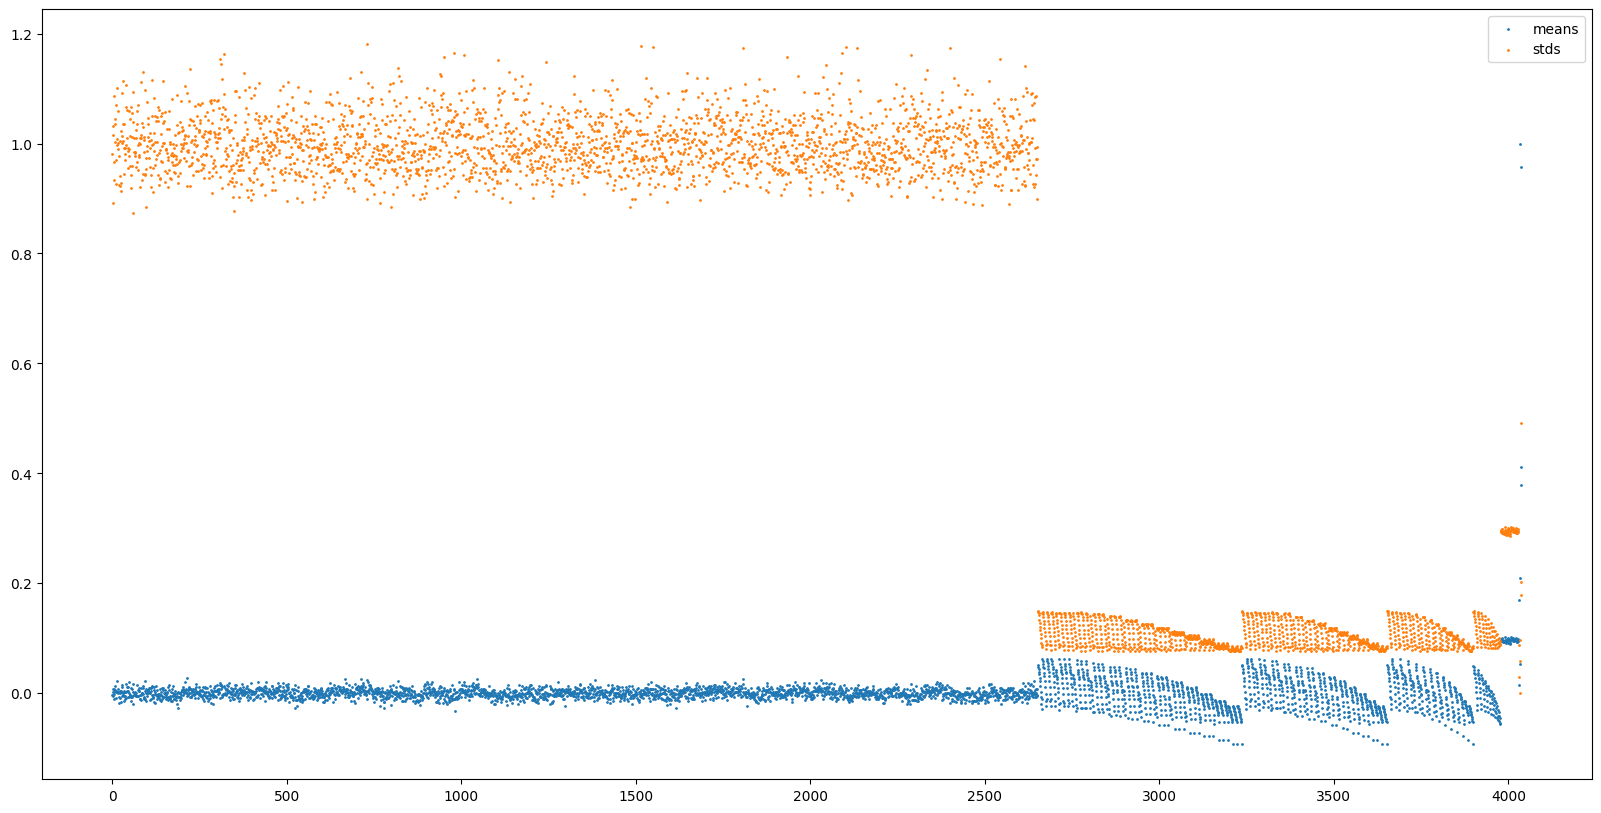

In [22]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means", s=1)
plt.scatter(range(df.std().size), df.std(), label="stds", s=1)
plt.legend()
plt.show()

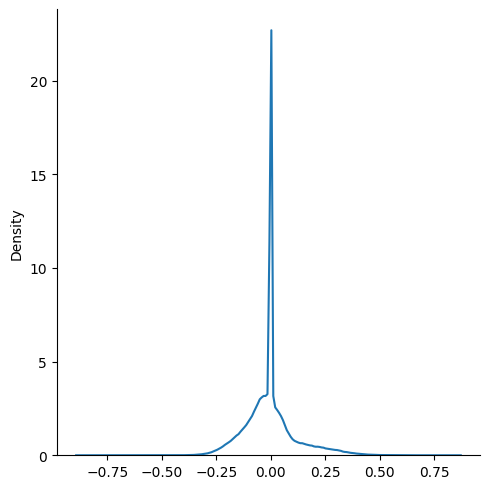

In [23]:
# Plot distribution of target values in a bell curve
from seaborn import displot

displot(raw_df[value_columns].to_numpy().flatten(), kind="kde")
plt.show()

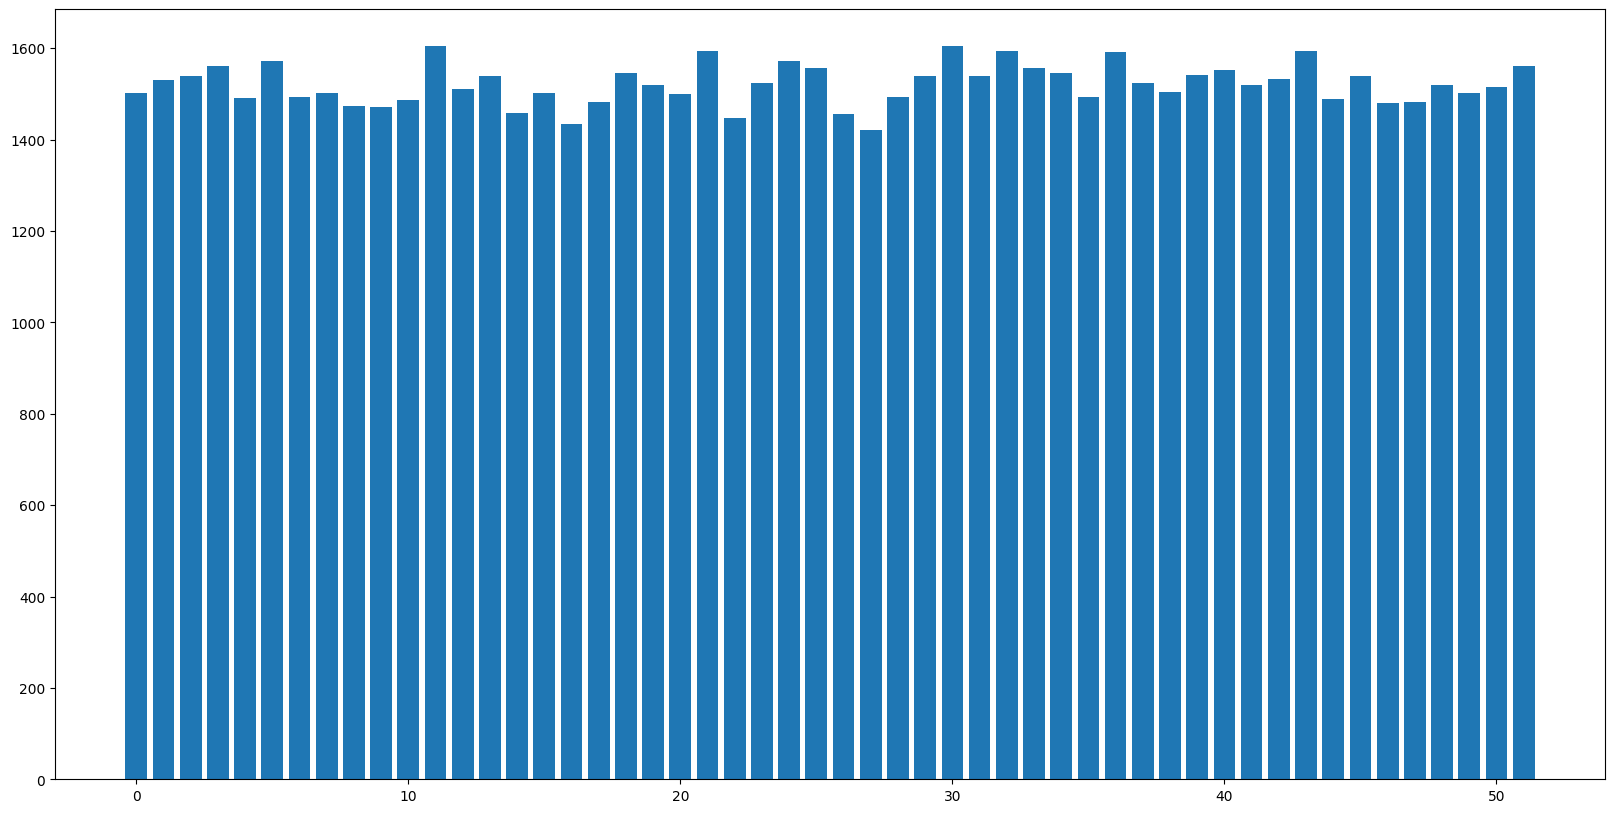

In [26]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_") and "*" not in col]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

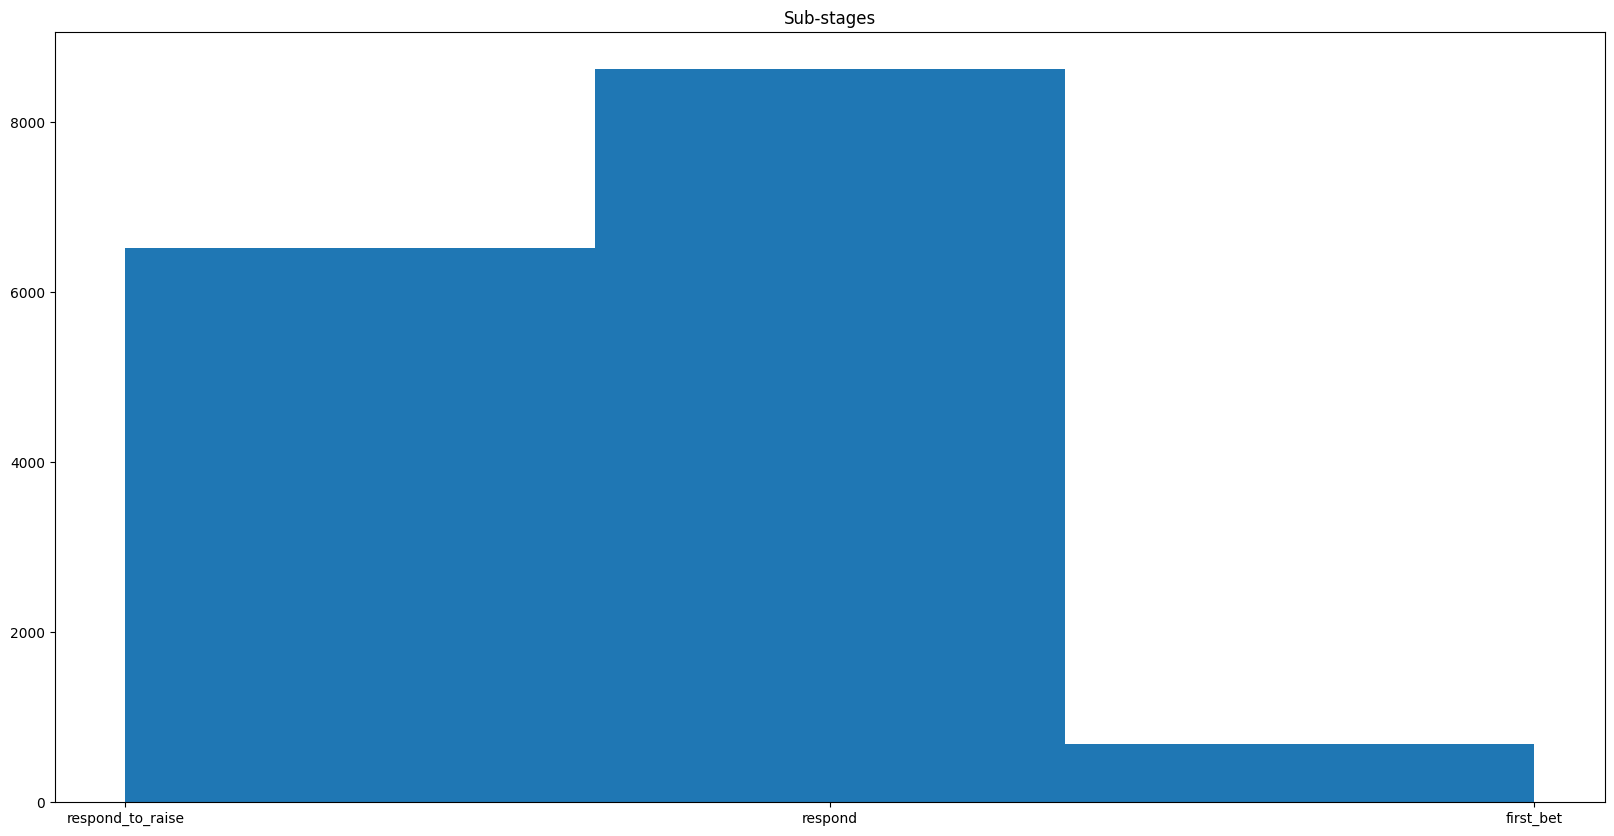

In [27]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [28]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(15822, 2712) (15822, 1326)


### Structure for Neural Network

In [29]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [30]:
def generate_model(l1_rate=1e-9, l2_rate=1e-8):
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define a small standard deviation for the initial weights
    init = RandomNormal(mean=0.0, stddev=0.002, seed=42)

    # Only use one hidden layer for now because we have so little data
    hidden_layer_1 = Dense(
        1326 * 2,
        activation="relu",
        name="hidden_layer_1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(input_layer)

    # hidden_layer_2 = Dense(
    #     1326 * 10,
    #     activation="relu",
    #     name="hidden_layer_2",
    #     kernel_initializer=init,
    #     kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    # )(hidden_layer_1)

    # hidden_layer_3 = Dense(
    #     1326 * 2,
    #     activation="relu",
    #     name="hidden_layer_3",
    #     kernel_initializer=init,
    #     kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    # )(hidden_layer_2)

    # Add a dropout layer to prevent overfitting
    dropout_layer = Dropout(0.5)(hidden_layer_1)

    # Define output layer
    value_layer_P1 = Dense(
        Y.shape[1],
        activation="linear",
        name="value_layer_P1",
        kernel_initializer=init,
        kernel_regularizer=l1_l2(l1=l1_rate, l2=l2_rate),
    )(dropout_layer)

    # Naturally, the target variable is centered around 0 with a SD of ~0.1, thus
    # to get an SD of 1, it is scaled by 10. To make this scaling implicit in the model,
    # rather than having to do it in the preprocessing, we add a scaling layer here.
    scaling_layer = Lambda(lambda x: x * 10)(value_layer_P1)

    # Create an Adam optimizer with a small learning rate
    small_lr_optimizer = Adam(learning_rate=0.000025)

    # Create model
    model = Model(inputs=input_layer, outputs=scaling_layer)
    model.compile(optimizer=small_lr_optimizer, loss="mean_squared_error")

    return model

### Cross validation

In [31]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []
validation_predictions = []
validation_actuals = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

folds = list(kf.split(X_train))
# folds = folds[:1] # Limit the number of folds to look at

# Loop over each fold
for i, (train_index, val_index) in enumerate(folds):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)
    validation_predictions.append(model.predict(X_val_fold))
    validation_actuals.append(Y_val_fold)

@@@ FOLD 1 @@@
Size of training set: 10125


2024-05-01 12:44:16.229113: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-05-01 12:44:16.229166: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-05-01 12:44:16.229176: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-05-01 12:44:16.229354: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-05-01 12:44:16.229730: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/1000


2024-05-01 12:44:16.939226: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


317/317 [==============================] - ETA: 0s - loss: 0.0245

...

80/80 [==============================] - 0s 3ms/step
@@@ FOLD 2 @@@
Size of training set: 10125
Epoch 1/1000
  1/317 [..............................] - ETA: 1:31 - loss: 0.0263

2024-05-01 12:46:56.933406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


317/317 [==============================] - ETA: 0s - loss: 0.0246

2024-05-01 12:47:07.084346: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


317/317 [==============================] - 11s 34ms/step - loss: 0.0246 - val_loss: 0.0132
Epoch 2/1000
317/317 [==============================] - 10s 32ms/step - loss: 0.0176 - val_loss: 0.0117
Epoch 3/1000
317/317 [==============================] - 10s 31ms/step - loss: 0.0146 - val_loss: 0.0109
Epoch 4/1000
 45/317 [===>..........................] - ETA: 7s - loss: 0.0140

In [199]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history['val_loss']
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
baseline_mse = np.mean((Y_test - np.mean(Y_train)) ** 2)
print(f"Baseline MSE: {baseline_mse:.4f}")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Cross-Validation MSE: 0.0100 (+/- 0.0000)
Baseline MSE: 0.0128
Cross-Validation RMSE: 0.0999 (+/- 0.0000)
Baseline RMSE: 0.1130


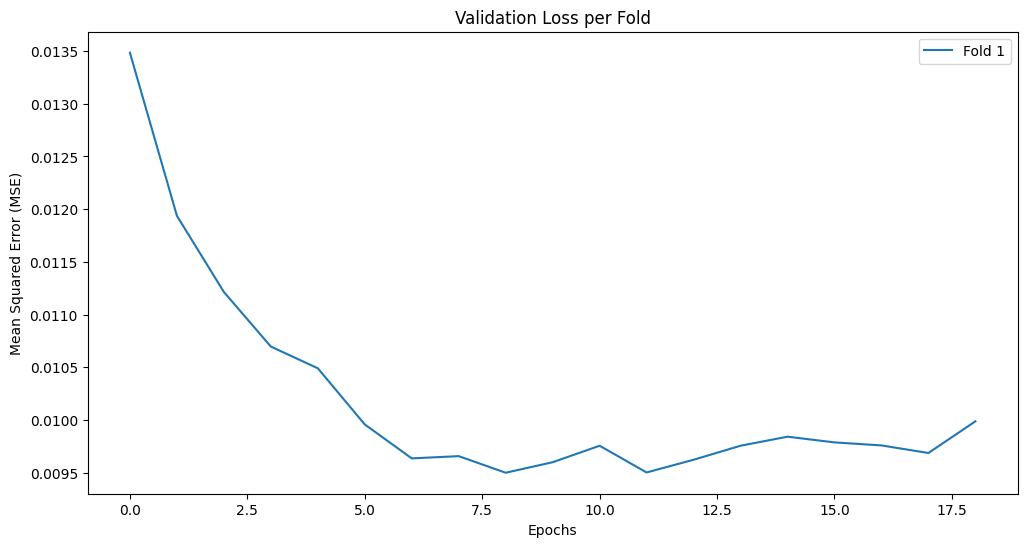

In [200]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

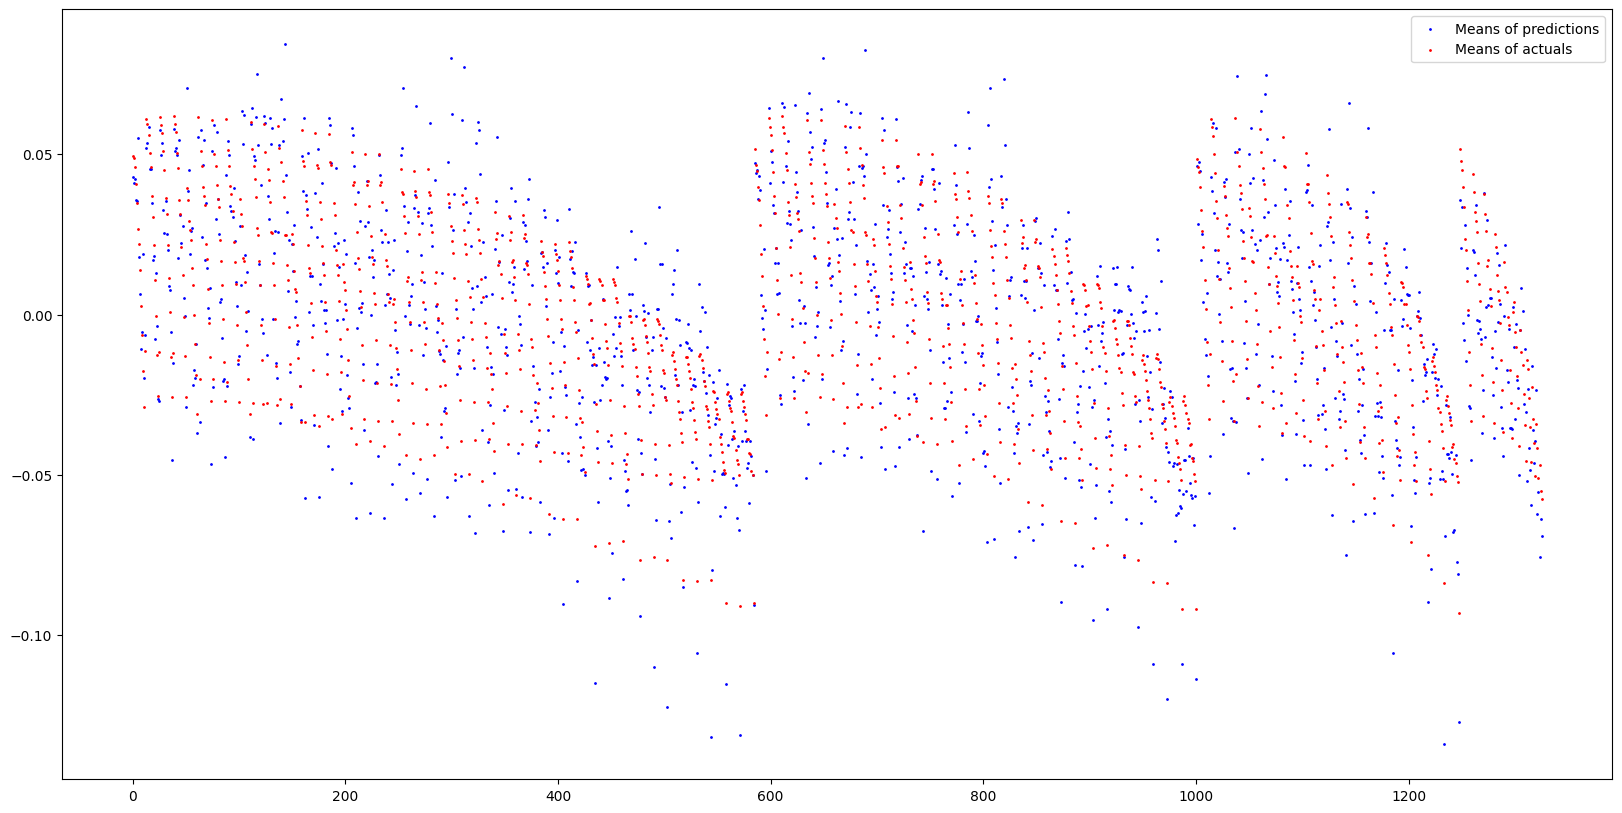

In [202]:
# Plot the distribution of outputs from the model
Y_val_pred = np.concatenate(validation_predictions)
Y_val = np.concatenate(validation_actuals)
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.mean(axis=0).size),
    Y_val_pred.mean(axis=0),
    label="Means of predictions",
    s=1,
    c="blue",
)
plt.scatter(
    range(Y_val.mean(axis=0).size),
    Y_val.mean(axis=0),
    label="Means of actuals",
    s=1,
    c="red",
)
plt.legend()
plt.show()

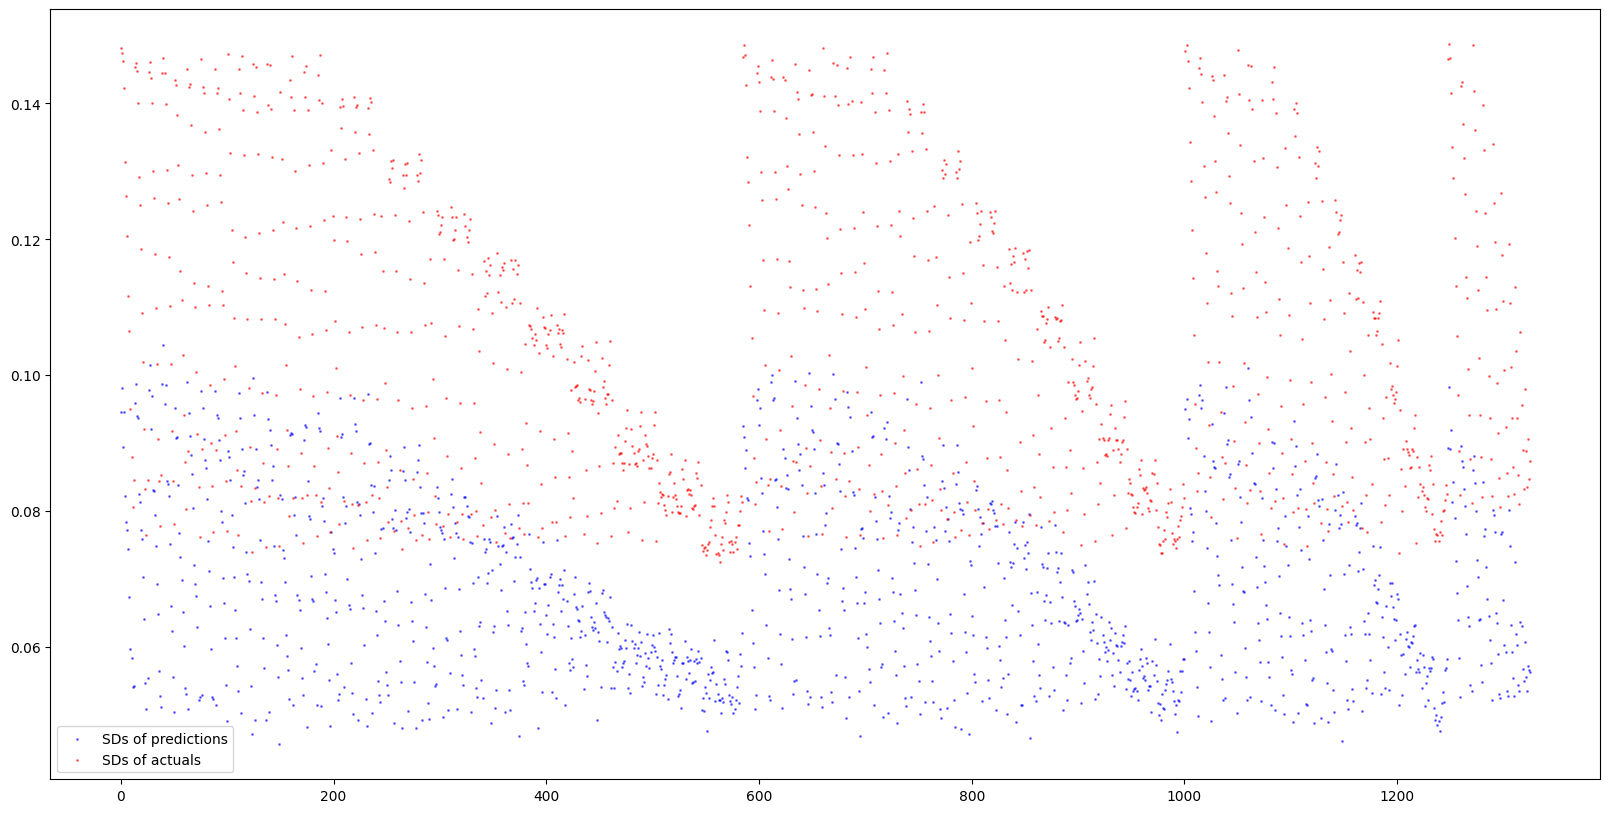

In [203]:
# Plot the distribution of outputs from the model
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(
    range(Y_val_pred.std(axis=0).size),
    Y_val_pred.std(axis=0),
    label="SDs of predictions",
    s=1,
    c="blue",
    alpha=0.5,
)
plt.scatter(
    range(Y_val.std(axis=0).size),
    Y_val.std(axis=0),
    label="SDs of actuals",
    s=1,
    c="red",
    alpha=0.5,
)
plt.legend()
plt.show()

In [204]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
buffer = 5  # Add a small buffer to avoid underfitting
final_epoch_number = int(average_optimal_epoch + buffer)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 13


### Testing

In [63]:
# Test the model
model = generate_model()
model.fit(X_train, Y_train, epochs=final_epoch_number)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

Epoch 1/59


2024-04-30 16:04:46.558371: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


282/282 [==============================] - 9s 32ms/step - loss: 0.3396
Epoch 2/59
282/282 [==============================] - 9s 31ms/step - loss: 0.2518
Epoch 3/59
282/282 [==============================] - 9s 31ms/step - loss: 0.1923
Epoch 4/59
282/282 [==============================] - 9s 30ms/step - loss: 0.1494
Epoch 5/59
282/282 [==============================] - 8s 30ms/step - loss: 0.1177
Epoch 6/59
282/282 [==============================] - 9s 30ms/step - loss: 0.0939
Epoch 7/59
282/282 [==============================] - 8s 30ms/step - loss: 0.0760
Epoch 8/59
282/282 [==============================] - 9s 31ms/step - loss: 0.0628
Epoch 9/59
282/282 [==============================] - 8s 30ms/step - loss: 0.0522
Epoch 10/59
282/282 [==============================] - 8s 30ms/step - loss: 0.0443
Epoch 11/59
282/282 [==============================] - 9s 31ms/step - loss: 0.0383
Epoch 12/59
282/282 [==============================] - 8s 30ms/step - loss: 0.0338
Epoch 13/59
282/282 [===

2024-04-30 16:13:13.390881: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


71/71 [==============================] - 1s 14ms/step - loss: 0.0110
Test MSE: 0.0110
Test RMSE: 0.1050


In [68]:
# As a baseline, calculate the RMSE of predicting only zeros
baseline_mse = np.mean(Y_test**2)
print(f"Baseline MSE: {baseline_mse:.4f}")
baseline_rmse = np.sqrt(baseline_mse)
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MSE: 0.0116
Baseline RMSE: 0.1079


In [ ]:
# As a better baseline, calculate the RMSE of predicting the mean of the target variable
mean_target = np.mean(Y_train)
mean_baseline_mse = np.mean((Y_test - mean_target)**2)
print(f"Mean Baseline MSE: {mean_baseline_mse:.4f}")
mean_baseline_rmse = np.sqrt(mean_baseline_mse)
print(f"Mean Baseline RMSE: {mean_baseline_rmse:.4f}")

### Training of final model

In [65]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=final_epoch_number)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

# Change working directory back to parent
os.chdir("..")

Epoch 1/59


2024-04-30 16:13:16.616904: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


352/352 [==============================] - 11s 31ms/step - loss: 0.3344
Epoch 2/59
352/352 [==============================] - 11s 30ms/step - loss: 0.2371
Epoch 3/59
352/352 [==============================] - 11s 31ms/step - loss: 0.1710
Epoch 4/59
352/352 [==============================] - 11s 30ms/step - loss: 0.1288
Epoch 5/59
352/352 [==============================] - 11s 31ms/step - loss: 0.0986
Epoch 6/59
352/352 [==============================] - 11s 30ms/step - loss: 0.0766
Epoch 7/59
352/352 [==============================] - 11s 31ms/step - loss: 0.0607
Epoch 8/59
352/352 [==============================] - 11s 30ms/step - loss: 0.0487
Epoch 9/59
352/352 [==============================] - 11s 31ms/step - loss: 0.0402
Epoch 10/59
352/352 [==============================] - 11s 30ms/step - loss: 0.0341
Epoch 11/59
352/352 [==============================] - 11s 31ms/step - loss: 0.0297
Epoch 12/59
352/352 [==============================] - 11s 30ms/step - loss: 0.0264
Epoch 13/59


/Users/tordjohanespe/Git/texas-holdem-ai/env/lib/python3.9/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [66]:
# Test making a point prediction
X_test_point = X_test[0].reshape(1, -1)
Y_test_point = Y_test[0].reshape(1, -1)
print("X_test_point shape:", X_test_point.shape)
Y_pred_point = model.predict(X_test_point)
print("Test point prediction:")
print("Actual:", Y_test_point)
print("Predicted:", Y_pred_point)

X_test_point shape: (1, 8016)
1/1 [==============================] - 0s 287ms/step
Test point prediction:
Actual: [[ 0.04346449  0.00213035  0.04186785 ... -0.02742999 -0.03084697
  -0.03596746]]
Predicted: [[ 0.0503009   0.03880732  0.04069597 ... -0.04314404 -0.05073707
  -0.05711745]]


2024-04-30 16:23:51.342015: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
